# Homesite Insurance — Temporal LightGBM Stability Notebook


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import importlib
import subprocess
import sys

def ensure_package(import_name, pip_name=None):
    try:
        importlib.import_module(import_name)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])

ensure_package("lightgbm", "lightgbm")
ensure_package("shap", "shap")
ensure_package("lime", "lime")

In [ ]:

import os
import gc
import ast
import json
import math
import random
import warnings
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import shap

from lime.lime_tabular import LimeTabularExplainer
from scipy.stats import wasserstein_distance
from itertools import combinations
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import precision_recall_curve, auc
from sklearn.model_selection import ParameterGrid

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 500)
pd.set_option("display.width", 1000)

## Configuration

In [ ]:
WINDOW_LENGTH_MONTHS = 9
RETRAIN_STEP_MONTHS = 4
EVAL_HORIZON_MONTHS = 4
PAIR_JUMP_MONTHS = 3

VALID_FRAC = 0.20
NUM_REPLICAS = 5
MAX_PAIRS = None

TUNING_TRIALS = 5
EARLY_STOPPING_ROUNDS = 40
N_ESTIMATORS = 300

USE_SHAP = True
USE_LIME = True
MAX_EXPLAIN_CASES = 200
MAX_LIME_CASES = 200
LIME_NUM_SAMPLES = 1000
EXPLAINER_NUM_RUNS = 5

FRAUD_THRESHOLD = 0.50

RBO_P = 0.90

SAVE_DIR = "/content/drive/MyDrive/Thesis 6/results_homesite_lgbm_temporal"
os.makedirs(SAVE_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

## Load the data

In [ ]:
PATH_CANDIDATES = [
    "/content/drive/MyDrive/Thesis 6/train.csv",
]

DATA_PATH = None
for path in PATH_CANDIDATES:
    if os.path.exists(path):
        DATA_PATH = path
        break

df = pd.read_csv(DATA_PATH)
print("Loaded from:", DATA_PATH)
print("Shape:", df.shape)
display(df.head())

Loaded from: /content/drive/MyDrive/Thesis 6/train.csv
Shape: (260753, 299)


,QuoteNumber,Original_Quote_Date,QuoteConversion_Flag,Field6,Field7,Field8,Field9,Field10,Field11,Field12,CoverageField1A,CoverageField1B,CoverageField2A,CoverageField2B,CoverageField3A,CoverageField3B,CoverageField4A,CoverageField4B,CoverageField5A,CoverageField5B,CoverageField6A,CoverageField6B,CoverageField8,CoverageField9,CoverageField11A,CoverageField11B,SalesField1A,SalesField1B,SalesField2A,SalesField2B,SalesField3,SalesField4,SalesField5,SalesField6,SalesField7,SalesField8,SalesField9,SalesField10,SalesField11,SalesField12,SalesField13,SalesField14,SalesField15,PersonalField1,PersonalField2,PersonalField4A,PersonalField4B,PersonalField5,PersonalField6,PersonalField7,PersonalField8,PersonalField9,PersonalField10A,PersonalField10B,PersonalField11,PersonalField12,PersonalField13,PersonalField14,PersonalField15,PersonalField16,PersonalField17,PersonalField18,PersonalField19,PersonalField22,PersonalField23,PersonalField24,PersonalField25,PersonalField26,PersonalField27,PersonalField28,PersonalField29,PersonalField30,PersonalField31,PersonalField32,PersonalField33,PersonalField34,PersonalField35,PersonalField36,PersonalField37,PersonalField38,PersonalField39,PersonalField40,PersonalField41,PersonalField42,PersonalField43,PersonalField44,PersonalField45,PersonalField46,PersonalField47,PersonalField48,PersonalField49,PersonalField50,PersonalField51,PersonalField52,PersonalField53,PersonalField54,PersonalField55,PersonalField56,PersonalField57,PersonalField58,PersonalField59,PersonalField60,PersonalField61,PersonalField62,PersonalField63,PersonalField64,PersonalField65,PersonalField66,PersonalField67,PersonalField68,PersonalField69,PersonalField70,PersonalField71,PersonalField72,PersonalField73,PersonalField74,PersonalField75,PersonalField76,PersonalField77,PersonalField78,PersonalField79,PersonalField80,PersonalField81,PersonalField82,PersonalField83,PersonalField84,PropertyField1A,PropertyField1B,PropertyField2A,PropertyField2B,PropertyField3,PropertyField4,PropertyField5,PropertyField6,PropertyField7,PropertyField8,PropertyField9,PropertyField10,PropertyField11A,PropertyField11B,PropertyField12,PropertyField13,PropertyField14,PropertyField15,PropertyField16A,PropertyField16B,PropertyField17,PropertyField18,PropertyField19,PropertyField20,PropertyField21A,PropertyField21B,PropertyField22,PropertyField23,PropertyField24A,PropertyField24B,PropertyField25,PropertyField26A,PropertyField26B,PropertyField27,PropertyField28,PropertyField29,PropertyField30,PropertyField31,PropertyField32,PropertyField33,PropertyField34,PropertyField35,PropertyField36,PropertyField37,PropertyField38,PropertyField39A,PropertyField39B,GeographicField1A,GeographicField1B,GeographicField2A,GeographicField2B,GeographicField3A,GeographicField3B,GeographicField4A,GeographicField4B,GeographicField5A,GeographicField5B,GeographicField6A,GeographicField6B,GeographicField7A,GeographicField7B,GeographicField8A,GeographicField8B,GeographicField9A,GeographicField9B,GeographicField10A,GeographicField10B,GeographicField11A,GeographicField11B,GeographicField12A,GeographicField12B,GeographicField13A,GeographicField13B,GeographicField14A,GeographicField14B,GeographicField15A,GeographicField15B,GeographicField16A,GeographicField16B,GeographicField17A,GeographicField17B,GeographicField18A,GeographicField18B,GeographicField19A,GeographicField19B,GeographicField20A,GeographicField20B,GeographicField21A,GeographicField21B,GeographicField22A,GeographicField22B,GeographicField23A,GeographicField23B,GeographicField24A,GeographicField24B,GeographicField25A,GeographicField25B,GeographicField26A,GeographicField26B,GeographicField27A,GeographicField27B,GeographicField28A,GeographicField28B,GeographicField29A,GeographicField29B,GeographicField30A,GeographicField30B,GeographicField31A,GeographicField31B,GeographicField32A,GeographicField32B,GeographicField33A,GeographicField33B,GeographicField34A,GeographicField34B,GeographicField35A,GeographicField35B,GeographicField36A,GeographicFie

## Build the monthly time structure

In [ ]:

DATE_COL = "Original_Quote_Date"
TARGET_COL = "QuoteConversion_Flag"
ID_COL = "QuoteNumber"

df = df.copy()
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL]).sort_values(DATE_COL).reset_index(drop=True)

df["quote_year"] = df[DATE_COL].dt.year
df["quote_quarter"] = df[DATE_COL].dt.quarter
df["quote_month"] = df[DATE_COL].dt.month
df["quote_day"] = df[DATE_COL].dt.day
df["quote_dayofweek"] = df[DATE_COL].dt.dayofweek
df["quote_dayofyear"] = df[DATE_COL].dt.dayofyear
df["quote_weekofyear"] = df[DATE_COL].dt.isocalendar().week.astype(int)
df["quote_is_month_start"] = df[DATE_COL].dt.is_month_start.astype(int)
df["quote_is_month_end"] = df[DATE_COL].dt.is_month_end.astype(int)

df["month_start"] = df[DATE_COL].dt.to_period("M").dt.to_timestamp()

month_lookup = pd.DataFrame({"month_start": sorted(df["month_start"].unique())})
month_lookup = month_lookup.sort_values("month_start").reset_index(drop=True)
month_lookup["time_step"] = np.arange(month_lookup.shape[0], dtype=int)
month_lookup["month_label"] = month_lookup["month_start"].dt.strftime("%Y-%m")

df = df.merge(month_lookup, on="month_start", how="left")

print("Monthly time steps created successfully.")
display(month_lookup.head(24))
display(df[[DATE_COL, "month_start", "month_label", "time_step"]].head(20))

Monthly time steps created successfully.


,month_start,time_step,month_label
0,2013-01-01,0,2013-01
1,2013-02-01,1,2013-02
2,2013-03-01,2,2013-03
3,2013-04-01,3,2013-04
4,2013-05-01,4,2013-05
5,2013-06-01,5,2013-06
6,2013-07-01,6,2013-07
7,2013-08-01,7,2013-08
8,2013-09-01,8,2013-09
9,2013-10-01,9,2013-10


,Original_Quote_Date,month_start,month_label,time_step
0,2013-01-01,2013-01-01,2013-01,0
1,2013-01-01,2013-01-01,2013-01,0
2,2013-01-01,2013-01-01,2013-01,0
3,2013-01-01,2013-01-01,2013-01,0
4,2013-01-01,2013-01-01,2013-01,0
5,2013-01-01,2013-01-01,2013-01,0
6,2013-01-01,2013-01-01,2013-01,0
7,2013-01-01,2013-01-01,2013-01,0
8,2013-01-01,2013-01-01,2013-01,0
9,2013-01-01,2013-01-01,2013-01,0


## Time EDA

,metric,value
0,n_rows,260753
1,n_columns,311
2,n_unique_ids,260753
3,start_date,2013-01-01 00:00:00
4,end_date,2015-05-18 00:00:00
5,n_month_steps,29
6,positive_rate,0.187511


,time_step,month_start,month_label,instances,positives,positive_rate
0,0,2013-01-01,2013-01,7195,1365,0.189715
1,1,2013-02-01,2013-02,6744,1370,0.203144
2,2,2013-03-01,2013-03,7493,1596,0.212999
3,3,2013-04-01,2013-04,8833,1884,0.213291
4,4,2013-05-01,2013-05,9413,1980,0.210347
5,5,2013-06-01,2013-06,9798,1951,0.199122
6,6,2013-07-01,2013-07,11241,2219,0.197402
7,7,2013-08-01,2013-08,11272,2211,0.196150
8,8,2013-09-01,2013-09,10245,2013,0.196486
9,9,2013-10-01,2013-10,10148,2165,0.213343


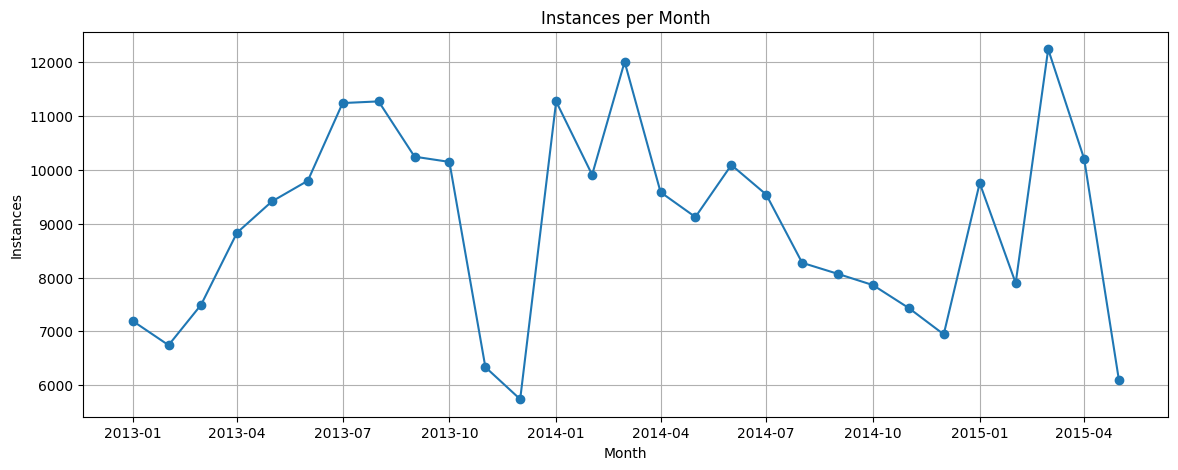

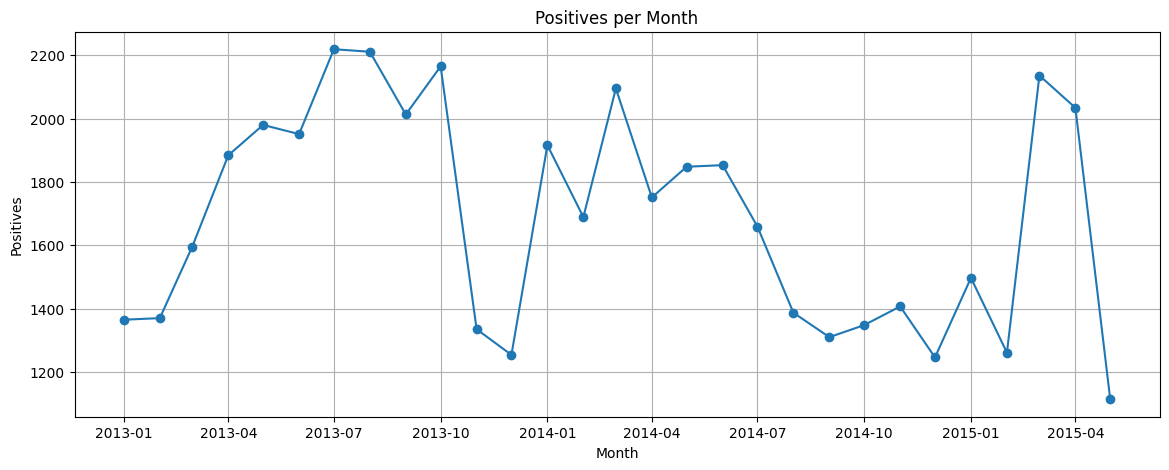

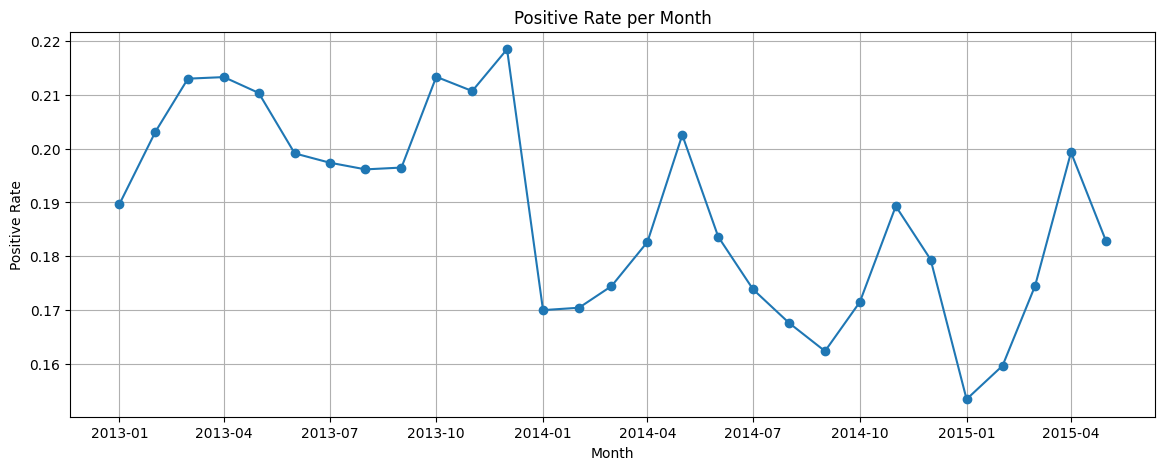

In [ ]:

overall_summary = pd.DataFrame({
    "metric": [
        "n_rows",
        "n_columns",
        "n_unique_ids",
        "start_date",
        "end_date",
        "n_month_steps",
        "positive_rate"
    ],
    "value": [
        len(df),
        df.shape[1],
        df[ID_COL].nunique(),
        df[DATE_COL].min(),
        df[DATE_COL].max(),
        df["time_step"].nunique(),
        df[TARGET_COL].mean()
    ]
})
display(overall_summary)

monthly_overview = (
    df.groupby(["time_step", "month_start", "month_label"], as_index=False)
      .agg(
          instances=(ID_COL, "count"),
          positives=(TARGET_COL, "sum")
      )
      .sort_values("time_step")
)
monthly_overview["positive_rate"] = monthly_overview["positives"] / monthly_overview["instances"]

display(monthly_overview)

plt.figure(figsize=(14, 5))
plt.plot(monthly_overview["month_start"], monthly_overview["instances"], marker="o")
plt.title("Instances per Month")
plt.xlabel("Month")
plt.ylabel("Instances")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(monthly_overview["month_start"], monthly_overview["positives"], marker="o")
plt.title("Positives per Month")
plt.xlabel("Month")
plt.ylabel("Positives")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(monthly_overview["month_start"], monthly_overview["positive_rate"], marker="o")
plt.title("Positive Rate per Month")
plt.xlabel("Month")
plt.ylabel("Positive Rate")
plt.grid(True)
plt.show()

## Define the raw feature space

In [ ]:

DROP_COLS = [TARGET_COL, ID_COL, DATE_COL, "month_start", "month_label"]
RAW_FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS and c != "time_step"]

num_cols_preview = [c for c in RAW_FEATURE_COLS if pd.api.types.is_numeric_dtype(df[c])]
cat_cols_preview = [c for c in RAW_FEATURE_COLS if c not in num_cols_preview]

schema_summary = pd.DataFrame({
    "group": ["raw_features", "numeric_features", "categorical_features"],
    "count": [len(RAW_FEATURE_COLS), len(num_cols_preview), len(cat_cols_preview)]
})
display(schema_summary)
print(RAW_FEATURE_COLS[:30])

,group,count
0,raw_features,305
1,numeric_features,278
2,categorical_features,27


['Field6', 'Field7', 'Field8', 'Field9', 'Field10', 'Field11', 'Field12', 'CoverageField1A', 'CoverageField1B', 'CoverageField2A', 'CoverageField2B', 'CoverageField3A', 'CoverageField3B', 'CoverageField4A', 'CoverageField4B', 'CoverageField5A', 'CoverageField5B', 'CoverageField6A', 'CoverageField6B', 'CoverageField8', 'CoverageField9', 'CoverageField11A', 'CoverageField11B', 'SalesField1A', 'SalesField1B', 'SalesField2A', 'SalesField2B', 'SalesField3', 'SalesField4', 'SalesField5']


## Core helper functions

In [ ]:
def split_columns(frame, feature_cols):
    numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(frame[c])]
    categorical_cols = [c for c in feature_cols if c not in numeric_cols]
    return numeric_cols, categorical_cols

def build_preprocessor(frame, feature_cols):
    numeric_cols, categorical_cols = split_columns(frame, feature_cols)

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1
        ))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ])

    feature_names = numeric_cols + categorical_cols
    return preprocessor, feature_names

def get_window_data(frame, end_step, window_length):
    start_step = end_step - window_length + 1
    mask = frame["time_step"].between(start_step, end_step)
    return frame.loc[mask].sort_values(DATE_COL).reset_index(drop=True)

def get_eval_slice(frame, start_step, horizon):
    mask = frame["time_step"].between(start_step + 1, start_step + horizon)
    return frame.loc[mask].sort_values(DATE_COL).reset_index(drop=True)

def split_train_valid_time(window_df, valid_frac=0.20):
    window_df = window_df.sort_values(DATE_COL).reset_index(drop=True)
    n = len(window_df)
    if n < 2:
        return window_df.copy(), window_df.iloc[0:0].copy()

    cut = int(np.floor(n * (1 - valid_frac)))
    cut = max(1, min(cut, n - 1))

    train_df = window_df.iloc[:cut].copy()
    valid_df = window_df.iloc[cut:].copy()
    return train_df, valid_df

def compute_scale_pos_weight(y):
    pos = float(np.sum(y == 1))
    neg = float(np.sum(y == 0))
    return neg / max(pos, 1.0)

def safe_pr_auc(y_true, y_score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    return auc(recall, precision)

def cosine_distance(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)

    if norm_a == 0 and norm_b == 0:
        return 0.0
    if norm_a == 0 or norm_b == 0:
        return 1.0

    return float(1.0 - np.dot(a, b) / (norm_a * norm_b))

def rank_features_by_magnitude(attr):
    return list(np.argsort(-np.abs(np.asarray(attr))).astype(int))

def compute_rbo(rank_a, rank_b, p=0.9):
    rank_a = list(rank_a)
    rank_b = list(rank_b)

    depth = max(len(rank_a), len(rank_b))
    seen_a = set()
    seen_b = set()
    cumulative = 0.0

    for d in range(1, depth + 1):
        if d <= len(rank_a):
            seen_a.add(rank_a[d - 1])
        if d <= len(rank_b):
            seen_b.add(rank_b[d - 1])

        overlap = len(seen_a.intersection(seen_b))
        cumulative += (overlap / d) * (p ** (d - 1))

    return float((1 - p) * cumulative)

def compute_baseline_instability(attr_all_replicas):
    num_replicas = len(attr_all_replicas)
    cosine_values = []
    rbo_values = []

    for r1, r2 in combinations(range(num_replicas), 2):
        attr_r1 = attr_all_replicas[r1]
        attr_r2 = attr_all_replicas[r2]

        cosine_values.append(cosine_distance(attr_r1, attr_r2))
        rbo_values.append(
            1 - compute_rbo(
                rank_features_by_magnitude(attr_r1),
                rank_features_by_magnitude(attr_r2),
                p=RBO_P
            )
        )

    return {
        "cosine_baseline": float(np.median(cosine_values)) if len(cosine_values) else np.nan,
        "rbo_baseline": float(np.median(rbo_values)) if len(rbo_values) else np.nan
    }

def compute_cross_window_instability(attr_a_replicas, attr_b_replicas):
    cosine_values = []
    rbo_values = []

    for attr_a in attr_a_replicas:
        for attr_b in attr_b_replicas:
            cosine_values.append(cosine_distance(attr_a, attr_b))
            rbo_values.append(
                1 - compute_rbo(
                    rank_features_by_magnitude(attr_a),
                    rank_features_by_magnitude(attr_b),
                    p=RBO_P
                )
            )

    return {
        "cosine_dynamic": float(np.mean(cosine_values)) if len(cosine_values) else np.nan,
        "rbo_dynamic": float(np.mean(rbo_values)) if len(rbo_values) else np.nan
    }

def compute_global_drift(attrib_a_avg, attrib_b_avg):
    global_importance_a = np.mean(np.abs(attrib_a_avg), axis=0)
    global_importance_b = np.mean(np.abs(attrib_b_avg), axis=0)

    rank_a = np.argsort(-global_importance_a)
    rank_b = np.argsort(-global_importance_b)

    global_drift = 1 - compute_rbo(rank_a, rank_b, p=RBO_P)
    return float(global_drift), global_importance_a, global_importance_b

## Reference preprocessing for covariate drift

In [ ]:
reference_preprocessor, reference_feature_names = build_preprocessor(df, RAW_FEATURE_COLS)
X_reference = reference_preprocessor.fit_transform(df[RAW_FEATURE_COLS])

reference_scaler = StandardScaler()
reference_scaler.fit(X_reference)

print("Reference preprocessor and scaler fitted for A-vs-B covariate drift.")
print(X_reference.shape)

Reference preprocessor and scaler fitted for A-vs-B covariate drift.
(260753, 305)


In [ ]:
def compute_covariate_drift(data_a, data_b):
    X_a = reference_preprocessor.transform(data_a[RAW_FEATURE_COLS])
    X_b = reference_preprocessor.transform(data_b[RAW_FEATURE_COLS])

    X_a_scaled = reference_scaler.transform(X_a)
    X_b_scaled = reference_scaler.transform(X_b)

    wasserstein_values = []
    for i in range(X_a_scaled.shape[1]):
        wd = wasserstein_distance(X_a_scaled[:, i], X_b_scaled[:, i])
        wasserstein_values.append(wd)

    return float(np.mean(wasserstein_values))

def compute_target_drift(data_a, data_b):
    fraud_rate_a = data_a[TARGET_COL].mean()
    fraud_rate_b = data_b[TARGET_COL].mean()
    return float(abs(fraud_rate_a - fraud_rate_b))

def compute_performance_change(replicas_a, replicas_b, eval_df):
    y_eval = eval_df[TARGET_COL].values

    pred_a = predict_replicas(replicas_a, eval_df)
    pred_b = predict_replicas(replicas_b, eval_df)

    pr_auc_a = safe_pr_auc(y_eval, pred_a)
    pr_auc_b = safe_pr_auc(y_eval, pred_b)

    loss_a = 1 - pr_auc_a if not np.isnan(pr_auc_a) else np.nan
    loss_b = 1 - pr_auc_b if not np.isnan(pr_auc_b) else np.nan

    delta_perf = loss_a - loss_b if not (np.isnan(loss_a) or np.isnan(loss_b)) else np.nan

    return (
        float(delta_perf) if not np.isnan(delta_perf) else np.nan,
        pr_auc_a,
        pr_auc_b
    )

## Model training

In [ ]:

def generate_param_candidates():
    grid = list(ParameterGrid({
        "learning_rate": [0.03, 0.05, 0.08],
        "num_leaves": [31, 63],
        "min_child_samples": [20, 50],
        "feature_fraction": [0.8, 1.0],
        "bagging_fraction": [0.8, 1.0],
        "lambda_l2": [0.0, 1.0]
    }))
    rng = np.random.RandomState(SEED)
    rng.shuffle(grid)
    return grid[:TUNING_TRIALS]

def fit_single_lgbm(X_train, y_train, X_valid, y_valid, params, seed):
    model = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=N_ESTIMATORS,
        random_state=seed,
        n_jobs=-1,
        verbosity=-1,
        scale_pos_weight=compute_scale_pos_weight(y_train),
        **params
    )
    callbacks = [lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)]
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="average_precision",
        callbacks=callbacks
    )
    return model

def tune_hyperparameters(train_df, valid_df):
    if len(train_df[TARGET_COL].unique()) < 2 or len(valid_df[TARGET_COL].unique()) < 2:
        default_params = {
            "learning_rate": 0.05,
            "num_leaves": 31,
            "min_child_samples": 20,
            "feature_fraction": 0.8,
            "bagging_fraction": 0.8,
            "lambda_l2": 0.0
        }
        return default_params, np.nan

    preprocessor, feature_names = build_preprocessor(train_df, RAW_FEATURE_COLS)
    X_train = preprocessor.fit_transform(train_df[RAW_FEATURE_COLS])
    X_valid = preprocessor.transform(valid_df[RAW_FEATURE_COLS])
    y_train = train_df[TARGET_COL].values
    y_valid = valid_df[TARGET_COL].values

    best_score = -np.inf
    best_params = None

    for trial_idx, params in enumerate(generate_param_candidates()):
        model = fit_single_lgbm(X_train, y_train, X_valid, y_valid, params, seed=SEED + trial_idx)
        pred_valid = model.predict_proba(X_valid)[:, 1]
        score = safe_pr_auc(y_valid, pred_valid)
        if np.isnan(score):
            score = -np.inf
        if score > best_score:
            best_score = score
            best_params = params

    if best_params is None:
        best_params = {
            "learning_rate": 0.05,
            "num_leaves": 31,
            "min_child_samples": 20,
            "feature_fraction": 0.8,
            "bagging_fraction": 0.8,
            "lambda_l2": 0.0
        }

    return best_params, best_score

def train_lgbm_replicas(window_df, num_replicas):
    train_df, valid_df = split_train_valid_time(window_df, valid_frac=VALID_FRAC)

    if len(train_df) == 0 or len(valid_df) == 0:
        raise ValueError("The train/valid split produced an empty partition.")

    best_params, best_score = tune_hyperparameters(train_df, valid_df)

    replicas = []
    for r in range(num_replicas):
        seed = SEED + r
        rng = np.random.RandomState(seed)

        y_train = train_df[TARGET_COL].values
        pos_idx = np.where(y_train == 1)[0]
        neg_idx = np.where(y_train == 0)[0]

        if len(pos_idx) == 0 or len(neg_idx) == 0:
            bootstrap_idx = rng.choice(np.arange(len(train_df)), size=len(train_df), replace=True)
        else:
            boot_pos = rng.choice(pos_idx, size=len(pos_idx), replace=True)
            boot_neg = rng.choice(neg_idx, size=len(neg_idx), replace=True)
            bootstrap_idx = np.concatenate([boot_pos, boot_neg])
            rng.shuffle(bootstrap_idx)

        boot_df = train_df.iloc[bootstrap_idx].copy().reset_index(drop=True)

        preprocessor, feature_names = build_preprocessor(boot_df, RAW_FEATURE_COLS)
        X_boot = preprocessor.fit_transform(boot_df[RAW_FEATURE_COLS])
        y_boot = boot_df[TARGET_COL].values
        X_valid = preprocessor.transform(valid_df[RAW_FEATURE_COLS])
        y_valid = valid_df[TARGET_COL].values

        model = fit_single_lgbm(X_boot, y_boot, X_valid, y_valid, best_params, seed=seed)

        replicas.append({
            "model": model,
            "preprocessor": preprocessor,
            "feature_names": feature_names,
            "train_df_raw": boot_df.copy(),
            "valid_df_raw": valid_df.copy()
        })

    return replicas, best_params, best_score

## Prediction and explanation functions

In [ ]:

def predict_replicas(replicas, eval_df):
    all_predictions = []
    for replica in replicas:
        X_eval = replica["preprocessor"].transform(eval_df[RAW_FEATURE_COLS])
        pred = replica["model"].predict_proba(X_eval)[:, 1]
        all_predictions.append(pred)
    return np.mean(np.vstack(all_predictions), axis=0)

def get_flagged_union(replicas_a, replicas_b, eval_df, threshold=0.5):
    pred_a = predict_replicas(replicas_a, eval_df)
    pred_b = predict_replicas(replicas_b, eval_df)
    flagged_a = pred_a >= threshold
    flagged_b = pred_b >= threshold
    return flagged_a, flagged_b, flagged_a | flagged_b, pred_a, pred_b

def get_best_replica_idx(replicas, eval_df):
    y_eval = eval_df[TARGET_COL].values
    scores = []
    for replica in replicas:
        X_eval = replica["preprocessor"].transform(eval_df[RAW_FEATURE_COLS])
        pred = replica["model"].predict_proba(X_eval)[:, 1]
        scores.append(safe_pr_auc(y_eval, pred))
    scores = np.array(scores, dtype=float)
    if np.all(np.isnan(scores)):
        return 0
    return int(np.nanargmax(scores))

def _normalize_shap_values(shap_values):
    shap_values = np.array(shap_values)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, -1]
    return shap_values

def compute_shap_attributions(replicas, eval_df):
    all_shap_values = []
    for replica in replicas:
        X_eval = replica["preprocessor"].transform(eval_df[RAW_FEATURE_COLS])
        explainer = shap.TreeExplainer(replica["model"])
        shap_values = explainer.shap_values(X_eval)
        shap_values = _normalize_shap_values(shap_values)
        all_shap_values.append(shap_values)
    avg_shap_values = np.mean(np.stack(all_shap_values, axis=0), axis=0)
    return avg_shap_values, all_shap_values

def compute_lime_attributions(replicas, eval_df, num_samples=LIME_NUM_SAMPLES):
    all_lime_values = []
    for r, replica in enumerate(replicas):
        X_train = replica["preprocessor"].transform(replica["train_df_raw"][RAW_FEATURE_COLS])
        X_eval = replica["preprocessor"].transform(eval_df[RAW_FEATURE_COLS])

        explainer = LimeTabularExplainer(
            X_train,
            feature_names=replica["feature_names"],
            class_names=["Negative", "Positive"],
            mode="classification",
            random_state=100 + r,
            discretize_continuous=False
        )

        lime_values = []
        for i in range(len(X_eval)):
            exp = explainer.explain_instance(
                X_eval[i],
                replica["model"].predict_proba,
                num_features=X_train.shape[1],
                num_samples=num_samples
            )
            attributions = np.zeros(X_train.shape[1])
            class_key = 1 if 1 in exp.local_exp else list(exp.local_exp.keys())[0]
            for feature_idx, attribution_value in exp.local_exp[class_key]:
                attributions[feature_idx] = attribution_value
            lime_values.append(attributions)

        all_lime_values.append(np.array(lime_values))

    avg_lime_values = np.mean(np.stack(all_lime_values, axis=0), axis=0)
    return avg_lime_values, all_lime_values

def compute_shap_explainer_instability(replica, eval_df, num_runs=EXPLAINER_NUM_RUNS):
    X_eval = replica["preprocessor"].transform(eval_df[RAW_FEATURE_COLS])
    explainer = shap.TreeExplainer(replica["model"])
    runs = []
    for _ in range(num_runs):
        shap_values = explainer.shap_values(X_eval)
        shap_values = _normalize_shap_values(shap_values)
        runs.append(shap_values)
    return runs

def compute_lime_explainer_instability(replica, eval_df, num_runs=EXPLAINER_NUM_RUNS, num_samples=LIME_NUM_SAMPLES):
    X_train = replica["preprocessor"].transform(replica["train_df_raw"][RAW_FEATURE_COLS])
    X_eval = replica["preprocessor"].transform(eval_df[RAW_FEATURE_COLS])
    runs = []
    for run in range(num_runs):
        explainer = LimeTabularExplainer(
            X_train,
            feature_names=replica["feature_names"],
            class_names=["Negative", "Positive"],
            mode="classification",
            random_state=100 + run,
            discretize_continuous=False
        )
        run_values = []
        for i in range(len(X_eval)):
            exp = explainer.explain_instance(
                X_eval[i],
                replica["model"].predict_proba,
                num_features=X_train.shape[1],
                num_samples=num_samples
            )
            attributions = np.zeros(X_train.shape[1])
            class_key = 1 if 1 in exp.local_exp else list(exp.local_exp.keys())[0]
            for feature_idx, attribution_value in exp.local_exp[class_key]:
                attributions[feature_idx] = attribution_value
            run_values.append(attributions)
        runs.append(np.array(run_values))
    return runs

## Main temporal experiment

In [ ]:
def build_valid_pairs(frame, window_length, retrain_step, eval_horizon, pair_jump):
    num_time_steps = int(frame["time_step"].nunique())
    valid_pairs = []

    start_end = window_length - 1
    max_end_a = num_time_steps - retrain_step - eval_horizon - 1

    for k_a in range(start_end, max_end_a + 1, pair_jump):
        k_b = k_a + retrain_step
        valid_pairs.append((k_a, k_b))

    return valid_pairs

def run_temporal_stability_experiment(frame):
    results = []

    valid_pairs = build_valid_pairs(
        frame=frame,
        window_length=WINDOW_LENGTH_MONTHS,
        retrain_step=RETRAIN_STEP_MONTHS,
        eval_horizon=EVAL_HORIZON_MONTHS,
        pair_jump=PAIR_JUMP_MONTHS
    )

    if MAX_PAIRS is not None:
        valid_pairs = valid_pairs[:MAX_PAIRS]

    print(f"Found {len(valid_pairs)} valid pairs")
    print(f"Window length: {WINDOW_LENGTH_MONTHS}")
    print(f"Retrain step: {RETRAIN_STEP_MONTHS}")
    print(f"Pair jump: {PAIR_JUMP_MONTHS}")
    print(f"Eval horizon: {EVAL_HORIZON_MONTHS}")
    print(f"Replicas: {NUM_REPLICAS}")
    print(f"SHAP: {USE_SHAP}")
    print(f"LIME: {USE_LIME}")

    for pair_idx, (k_a, k_b) in enumerate(valid_pairs):
        print()
        print("=" * 100)
        print(f"Pair {pair_idx + 1}/{len(valid_pairs)}")
        print(f"Window A ends at time_step={k_a}")
        print(f"Window B ends at time_step={k_b}")
        print("=" * 100)

        window_a = get_window_data(frame, k_a, WINDOW_LENGTH_MONTHS)
        window_b = get_window_data(frame, k_b, WINDOW_LENGTH_MONTHS)

        eval_slice = get_eval_slice(frame, k_b, EVAL_HORIZON_MONTHS)

        if len(window_a) < 50 or len(window_b) < 50 or len(eval_slice) == 0:
            print("Skipping pair because one partition is too small.")
            continue

        print(f"Window A size: {len(window_a)} | positive rate: {window_a[TARGET_COL].mean():.4f}")
        print(f"Window B size: {len(window_b)} | positive rate: {window_b[TARGET_COL].mean():.4f}")
        print(f"Eval size: {len(eval_slice)} | positive rate: {eval_slice[TARGET_COL].mean():.4f}")
        print(f"Eval months: {sorted(eval_slice['month_label'].unique().tolist())}")

        replicas_a, best_params_a, best_score_a = train_lgbm_replicas(window_a, NUM_REPLICAS)
        replicas_b, best_params_b, best_score_b = train_lgbm_replicas(window_b, NUM_REPLICAS)

        flagged_a, flagged_b, flagged_union, pred_a_mean, pred_b_mean = get_flagged_union(
            replicas_a,
            replicas_b,
            eval_slice,
            threshold=FRAUD_THRESHOLD
        )

        num_flagged = int(flagged_union.sum())
        pct_flagged = 100 * num_flagged / len(eval_slice)

        if num_flagged == 0:
            order = np.argsort(-(0.5 * pred_a_mean + 0.5 * pred_b_mean))
            fallback_n = min(MAX_EXPLAIN_CASES, len(eval_slice))
            flagged_union = np.zeros(len(eval_slice), dtype=bool)
            flagged_union[order[:fallback_n]] = True
            num_flagged = int(flagged_union.sum())
            pct_flagged = 100 * num_flagged / len(eval_slice)

        covariate_drift = compute_covariate_drift(window_a, window_b)
        target_drift = compute_target_drift(window_a, window_b)
        delta_perf, pr_auc_a, pr_auc_b = compute_performance_change(replicas_a, replicas_b, eval_slice)

        result = {
            "pair_idx": pair_idx,
            "window_a_end": k_a,
            "window_b_end": k_b,
            "window_a_months": str(sorted(window_a["month_label"].unique().tolist())),
            "window_b_months": str(sorted(window_b["month_label"].unique().tolist())),
            "eval_months": str(sorted(eval_slice["month_label"].unique().tolist())),
            "window_a_size": len(window_a),
            "window_b_size": len(window_b),
            "eval_size": len(eval_slice),
            "window_a_positive_rate": float(window_a[TARGET_COL].mean()),
            "window_b_positive_rate": float(window_b[TARGET_COL].mean()),
            "eval_positive_rate": float(eval_slice[TARGET_COL].mean()),
            "num_flagged": num_flagged,
            "pct_flagged": pct_flagged,
            "covariate_drift": covariate_drift,
            "target_drift": target_drift,
            "pr_auc_a": pr_auc_a,
            "pr_auc_b": pr_auc_b,
            "delta_perf": delta_perf,
            "best_params_a": json.dumps(best_params_a),
            "best_params_b": json.dumps(best_params_b),
            "best_valid_pr_auc_a": best_score_a,
            "best_valid_pr_auc_b": best_score_b
        }

        eval_flagged = eval_slice.loc[flagged_union].copy().reset_index(drop=True)
        if len(eval_flagged) > MAX_EXPLAIN_CASES:
            eval_flagged = eval_flagged.iloc[:MAX_EXPLAIN_CASES].copy().reset_index(drop=True)

        if USE_SHAP and len(eval_flagged) > 0:
            print(f"Computing SHAP on {len(eval_flagged)} cases")

            shap_a_avg, shap_a_all = compute_shap_attributions(replicas_a, eval_flagged)
            shap_b_avg, shap_b_all = compute_shap_attributions(replicas_b, eval_flagged)

            dynamic_cos_values = []
            dynamic_rbo_values = []
            static_cos_a_values = []
            static_rbo_a_values = []
            static_cos_b_values = []
            static_rbo_b_values = []

            for i in range(len(eval_flagged)):
                dynamic_metrics = compute_cross_window_instability(
                    [shap_a_all[r][i] for r in range(NUM_REPLICAS)],
                    [shap_b_all[r][i] for r in range(NUM_REPLICAS)]
                )

                static_a = compute_baseline_instability(
                    [shap_a_all[r][i] for r in range(NUM_REPLICAS)]
                )
                static_b = compute_baseline_instability(
                    [shap_b_all[r][i] for r in range(NUM_REPLICAS)]
                )

                dynamic_cos_values.append(dynamic_metrics["cosine_dynamic"])
                dynamic_rbo_values.append(dynamic_metrics["rbo_dynamic"])
                static_cos_a_values.append(static_a["cosine_baseline"])
                static_rbo_a_values.append(static_a["rbo_baseline"])
                static_cos_b_values.append(static_b["cosine_baseline"])
                static_rbo_b_values.append(static_b["rbo_baseline"])

            result["shap_dynamic_cos"] = float(np.median(dynamic_cos_values))
            result["shap_dynamic_rbo"] = float(np.median(dynamic_rbo_values))
            result["shap_static_cos_a"] = float(np.median(static_cos_a_values))
            result["shap_static_rbo_a"] = float(np.median(static_rbo_a_values))
            result["shap_static_cos_b"] = float(np.median(static_cos_b_values))
            result["shap_static_rbo_b"] = float(np.median(static_rbo_b_values))
            result["shap_static_cos_mean"] = float((result["shap_static_cos_a"] + result["shap_static_cos_b"]) / 2)
            result["shap_static_rbo_mean"] = float((result["shap_static_rbo_a"] + result["shap_static_rbo_b"]) / 2)

            eps = 1e-10
            result["shap_drift_ratio_cos"] = float(result["shap_dynamic_cos"] / (result["shap_static_cos_mean"] + eps))
            result["shap_drift_ratio_rbo"] = float(result["shap_dynamic_rbo"] / (result["shap_static_rbo_mean"] + eps))

            shap_global_drift, shap_global_imp_a, shap_global_imp_b = compute_global_drift(shap_a_avg, shap_b_avg)
            result["shap_global_drift"] = shap_global_drift

            best_idx_a = get_best_replica_idx(replicas_a, eval_slice)
            shap_explainer_runs = compute_shap_explainer_instability(
                replicas_a[best_idx_a],
                eval_flagged,
                num_runs=EXPLAINER_NUM_RUNS
            )

            shap_explainer_cos = []
            shap_explainer_rbo = []

            for i in range(len(eval_flagged)):
                expl_instab = compute_baseline_instability(
                    [shap_explainer_runs[run][i] for run in range(EXPLAINER_NUM_RUNS)]
                )
                shap_explainer_cos.append(expl_instab["cosine_baseline"])
                shap_explainer_rbo.append(expl_instab["rbo_baseline"])

            result["shap_explainer_instability_cos"] = float(np.median(shap_explainer_cos))
            result["shap_explainer_instability_rbo"] = float(np.median(shap_explainer_rbo))

        if USE_LIME and len(eval_flagged) > 0:
            eval_lime = eval_flagged.copy()
            if len(eval_lime) > MAX_LIME_CASES:
                eval_lime = eval_lime.iloc[:MAX_LIME_CASES].copy().reset_index(drop=True)

            print(f"Computing LIME on {len(eval_lime)} cases")

            lime_a_avg, lime_a_all = compute_lime_attributions(
                replicas_a,
                eval_lime,
                num_samples=LIME_NUM_SAMPLES
            )
            lime_b_avg, lime_b_all = compute_lime_attributions(
                replicas_b,
                eval_lime,
                num_samples=LIME_NUM_SAMPLES
            )

            dynamic_cos_values = []
            dynamic_rbo_values = []
            static_cos_a_values = []
            static_rbo_a_values = []
            static_cos_b_values = []
            static_rbo_b_values = []

            for i in range(len(eval_lime)):
                dynamic_metrics = compute_cross_window_instability(
                    [lime_a_all[r][i] for r in range(NUM_REPLICAS)],
                    [lime_b_all[r][i] for r in range(NUM_REPLICAS)]
                )

                static_a = compute_baseline_instability(
                    [lime_a_all[r][i] for r in range(NUM_REPLICAS)]
                )
                static_b = compute_baseline_instability(
                    [lime_b_all[r][i] for r in range(NUM_REPLICAS)]
                )

                dynamic_cos_values.append(dynamic_metrics["cosine_dynamic"])
                dynamic_rbo_values.append(dynamic_metrics["rbo_dynamic"])
                static_cos_a_values.append(static_a["cosine_baseline"])
                static_rbo_a_values.append(static_a["rbo_baseline"])
                static_cos_b_values.append(static_b["cosine_baseline"])
                static_rbo_b_values.append(static_b["rbo_baseline"])

            result["lime_dynamic_cos"] = float(np.median(dynamic_cos_values))
            result["lime_dynamic_rbo"] = float(np.median(dynamic_rbo_values))
            result["lime_static_cos_a"] = float(np.median(static_cos_a_values))
            result["lime_static_rbo_a"] = float(np.median(static_rbo_a_values))
            result["lime_static_cos_b"] = float(np.median(static_cos_b_values))
            result["lime_static_rbo_b"] = float(np.median(static_rbo_b_values))
            result["lime_static_cos_mean"] = float((result["lime_static_cos_a"] + result["lime_static_cos_b"]) / 2)
            result["lime_static_rbo_mean"] = float((result["lime_static_rbo_a"] + result["lime_static_rbo_b"]) / 2)

            eps = 1e-10
            result["lime_drift_ratio_cos"] = float(result["lime_dynamic_cos"] / (result["lime_static_cos_mean"] + eps))
            result["lime_drift_ratio_rbo"] = float(result["lime_dynamic_rbo"] / (result["lime_static_rbo_mean"] + eps))

            lime_global_drift, lime_global_imp_a, lime_global_imp_b = compute_global_drift(lime_a_avg, lime_b_avg)
            result["lime_global_drift"] = lime_global_drift

            best_idx_a = get_best_replica_idx(replicas_a, eval_slice)
            lime_explainer_runs = compute_lime_explainer_instability(
                replicas_a[best_idx_a],
                eval_lime,
                num_runs=EXPLAINER_NUM_RUNS,
                num_samples=LIME_NUM_SAMPLES
            )

            lime_explainer_cos = []
            lime_explainer_rbo = []

            for i in range(len(eval_lime)):
                expl_instab = compute_baseline_instability(
                    [lime_explainer_runs[run][i] for run in range(EXPLAINER_NUM_RUNS)]
                )
                lime_explainer_cos.append(expl_instab["cosine_baseline"])
                lime_explainer_rbo.append(expl_instab["rbo_baseline"])

            result["lime_explainer_instability_cos"] = float(np.median(lime_explainer_cos))
            result["lime_explainer_instability_rbo"] = float(np.median(lime_explainer_rbo))

        results.append(result)

        print("Table 1: Performance and A-vs-B data drift")
        display(pd.DataFrame([{
            "pr_auc_a": result["pr_auc_a"],
            "pr_auc_b": result["pr_auc_b"],
            "delta_perf": result["delta_perf"],
            "target_drift": result["target_drift"],
            "covariate_drift": result["covariate_drift"],
            "num_flagged": result["num_flagged"],
            "pct_flagged": result["pct_flagged"]
        }]))

        summary_rows = []

        if "shap_dynamic_cos" in result:
            summary_rows.append({
                "method": "SHAP",
                "static_cos_a": result["shap_static_cos_a"],
                "static_cos_b": result["shap_static_cos_b"],
                "static_cos_mean": result["shap_static_cos_mean"],
                "dynamic_cos": result["shap_dynamic_cos"],
                "drift_ratio_cos": result["shap_drift_ratio_cos"],
                "global_drift": result["shap_global_drift"],
                "explainer_instability_cos": result["shap_explainer_instability_cos"]
            })

        if "lime_dynamic_cos" in result:
            summary_rows.append({
                "method": "LIME",
                "static_cos_a": result["lime_static_cos_a"],
                "static_cos_b": result["lime_static_cos_b"],
                "static_cos_mean": result["lime_static_cos_mean"],
                "dynamic_cos": result["lime_dynamic_cos"],
                "drift_ratio_cos": result["lime_drift_ratio_cos"],
                "global_drift": result["lime_global_drift"],
                "explainer_instability_cos": result["lime_explainer_instability_cos"]
            })

        if len(summary_rows):
            print("Table 2: Explanation stability summary")
            display(pd.DataFrame(summary_rows))

        gc.collect()

    return pd.DataFrame(results)

## Run the experiment

In [ ]:
results_df = run_temporal_stability_experiment(df)

print("Experiment completed.")
display(results_df.head())
print(results_df.shape)

Found 5 valid pairs
Window length: 9
Retrain step: 4
Pair jump: 3
Eval horizon: 4
Replicas: 5
SHAP: True
LIME: True

Pair 1/5
Window A ends at time_step=8
Window B ends at time_step=12
Window A size: 82234 | positive rate: 0.2017
Window B size: 85463 | positive rate: 0.1994
Eval size: 40626 | positive rate: 0.1817
Eval months: ['2014-02', '2014-03', '2014-04', '2014-05']
Computing SHAP on 200 cases
Computing LIME on 200 cases
Table 1: Performance and A-vs-B data drift


,pr_auc_a,pr_auc_b,delta_perf,target_drift,covariate_drift,num_flagged,pct_flagged
0,0.895004,0.89524,0.000236,0.002298,0.031787,9050,22.276375


Table 2: Explanation stability summary


,method,static_cos_a,static_cos_b,static_cos_mean,dynamic_cos,drift_ratio_cos,global_drift,explainer_instability_cos
0,SHAP,0.026501,0.043176,0.034839,0.062708,1.799941,0.132530,0.000000
1,LIME,0.376402,0.357080,0.366741,0.322970,0.880650,0.167523,0.310517



Pair 2/5
Window A ends at time_step=11
Window B ends at time_step=15
Window A size: 83026 | positive rate: 0.2049
Window B size: 86513 | positive rate: 0.1899
Eval size: 37031 | positive rate: 0.1822
Eval months: ['2014-05', '2014-06', '2014-07', '2014-08']
Computing SHAP on 200 cases
Computing LIME on 200 cases
Table 1: Performance and A-vs-B data drift


...

Table 2: Explanation stability summary


,method,static_cos_a,static_cos_b,static_cos_mean,dynamic_cos,drift_ratio_cos,global_drift,explainer_instability_cos
0,SHAP,0.028110,0.016904,0.022507,0.04907,2.180244,0.204188,0.000000
1,LIME,0.326781,0.365307,0.346044,0.30484,0.880929,0.210433,0.312731


Experiment completed.


,pair_idx,window_a_end,window_b_end,window_a_months,window_b_months,eval_months,window_a_size,window_b_size,eval_size,window_a_positive_rate,window_b_positive_rate,eval_positive_rate,num_flagged,pct_flagged,covariate_drift,target_drift,pr_auc_a,pr_auc_b,delta_perf,best_params_a,best_params_b,best_valid_pr_auc_a,best_valid_pr_auc_b,shap_dynamic_cos,shap_dynamic_rbo,shap_static_cos_a,shap_static_rbo_a,shap_static_cos_b,shap_static_rbo_b,shap_static_cos_mean,shap_static_rbo_mean,shap_drift_ratio_cos,shap_drift_ratio_rbo,shap_global_drift,shap_explainer_instability_cos,shap_explainer_instability_rbo,lime_dynamic_cos,lime_dynamic_rbo,lime_static_cos_a,lime_static_rbo_a,lime_static_cos_b,lime_static_rbo_b,lime_static_cos_mean,lime_static_rbo_mean,lime_drift_ratio_cos,lime_drift_ratio_rbo,lime_global_drift,lime_explainer_instability_cos,lime_explainer_instability_rbo
0,0,8,12,"['2013-01', '2013-02', '2013-03', '2013-04', '...","['2013-05', '2013-06', '2013-07', '2013-08', '...","['2014-02', '2014-03', '2014-04', '2014-05']",82234,85463,40626,0.201729,0.199431,0.181731,9050,22.276375,0.031787,0.002298,0.895004,0.895240,0.000236,"{""bagging_fraction"": 1.0, ""feature_fraction"": ...","{""bagging_fraction"": 1.0, ""feature_fraction"": ...",0.900190,0.890912,0.062708,0.208360,0.026501,0.170295,0.043176,0.169527,0.034839,0.169911,1.799941,1.226285,0.132530,0.0,1.143530e-14,0.322970,0.488920,0.376402,0.497242,0.357080,0.541714,0.366741,0.519478,0.880650,0.941176,0.167523,0.310517,0.529254
1,1,11,15,"['2013-04', '2013-05', '2013-06', '2013-07', '...","['2013-08', '2013-09', '2013-10', '2013-11', '...","['2014-05', '2014-06', '2014-07', '2014-08']",83026,86513,37031,0.204900,0.189902,0.182199,8797,23.755772,0.033510,0.014998,0.893592,0.895374,0.001782,"{""bagging_fraction"": 1.0, ""feature_fraction"": ...","{""bagging_fraction"": 1.0, ""feature_fraction"": ...",0.896993,0.900223,0.033324,0.170258,0.021295,0.135710,0.017848,0.150171,0.019572,0.142940,1.702676,1.191111,0.122670,0.0,1.143530e-14,0.305576,0.451831,0.355530,0.466492,0.335706,0.464970,0.345618,0.465731,0.884143,0.970153,0.133048,0.326542,0.450446
2,2,14,18,"['2013-07', '2013-08', '2013-09', '2013-10', '...","['2013-11', '2013-12', '2014-01', '2014-02', '...","['2014-08', '2014-09', '2014-10', '2014-11']",88169,83605,31633,0.191643,0.184200,0.172352,7222,22.830588,0.055231,0.007444,0.865304,0.870673,0.005369,"{""bagging_fraction"": 1.0, ""feature_fraction"": ...","{""bagging_fraction"": 1.0, ""feature_fraction"": ...",0.894834,0.902245,0.035354,0.177936,0.019849,0.140636,0.028768,0.160554,0.024308,0.150595,1.454405,1.181548,0.063797,0.0,1.143530e-14,0.267170,0.484432,0.324955,0.474087,0.308389,0.551637,0.316672,0.512862,0.843681,0.944567,0.155453,0.304517,0.491057
3,3,17,21,"['2013-10', '2013-11', '2013-12', '2014-01', '...","['2014-02', '2014-03', '2014-04', '2014-05', '...","['2014-11', '2014-12', '2015-01', '2015-02']",84211,84460,32029,0.188883,0.176888,0.168941,7290,22.760623,0.054513,0.011994,0.842835,0.846326,0.003492,"{""bagging_fraction"": 1.0, ""feature_fraction"": ...","{""bagging_fraction"": 1.0, ""feature_fraction"": ...",0.905609,0.875847,0.033812,0.174435,0.030136,0.163327,0.018483,0.127072,0.024309,0.145199,1.390901,1.201344,0.065153,0.0,1.143530e-14,0.278521,0.455979,0.325358,0.540196,0.330437,0.432936,0.327898,0.486566,0.849414,0.937136,0.160893,0.315873,0.460269
4,4,20,24,"['2014-01', '2014-02', '2014-03', '2014-04', '...","['2014-05', '2014-06', '2014-07', '2014-08', '...","['2015-02', '2015-03', '2015-04', '2015-05']",87870,77090,36433,0.176488,0.175833,0.179645,7900,21.683638,0.054699,0.000655,0.871977,0.874168,0.002191,"{""bagging_fraction"": 1.0, ""feature_fraction"": ...","{""bagging_fraction"": 1.0, ""feature_fraction"": ...",0.873017,0.836779,0.049070,0.208004,0.028110,0.166945,0.016904,0.146846,0.022507,0.156895,2.180244,1.325749,0.204188,0.0,1.143530e-14,0.304840,0.438867,0.326781,0.473536,0.365307,0.448779,0.346044,0.461157,0.880929,0.951664,0.210433,0

(5, 49)


## Save the results

In [ ]:

results_csv_path = os.path.join(SAVE_DIR, "homesite_temporal_lgbm_results.csv")
results_pkl_path = os.path.join(SAVE_DIR, "homesite_temporal_lgbm_results.pkl")

results_df.to_csv(results_csv_path, index=False)
results_df.to_pickle(results_pkl_path)

print(results_csv_path)
print(results_pkl_path)

/content/drive/MyDrive/Thesis 6/results_homesite_lgbm_temporal/homesite_temporal_lgbm_results.csv
/content/drive/MyDrive/Thesis 6/results_homesite_lgbm_temporal/homesite_temporal_lgbm_results.pkl


## Summary tables

In [ ]:

print("=" * 100)
print("TEMPORAL STABILITY ANALYSIS - SUMMARY")
print("=" * 100)

if len(results_df) == 0:
    print("No results were produced.")
else:
    summary_items = {
        "n_pairs": len(results_df),
        "mean_covariate_drift": results_df["covariate_drift"].mean() if "covariate_drift" in results_df.columns else np.nan,
        "mean_target_drift": results_df["target_drift"].mean() if "target_drift" in results_df.columns else np.nan,
        "mean_pr_auc_a": results_df["pr_auc_a"].mean() if "pr_auc_a" in results_df.columns else np.nan,
        "mean_pr_auc_b": results_df["pr_auc_b"].mean() if "pr_auc_b" in results_df.columns else np.nan,
        "mean_delta_perf": results_df["delta_perf"].mean() if "delta_perf" in results_df.columns else np.nan,
        "mean_num_flagged": results_df["num_flagged"].mean() if "num_flagged" in results_df.columns else np.nan
    }
    display(pd.DataFrame([summary_items]))

    shap_cols = [c for c in [
        "shap_static_cos_a", "shap_static_cos_b", "shap_static_cos_mean",
        "shap_dynamic_cos", "shap_drift_ratio_cos", "shap_global_drift",
        "shap_explainer_instability_cos"
    ] if c in results_df.columns]

    lime_cols = [c for c in [
        "lime_static_cos_a", "lime_static_cos_b", "lime_static_cos_mean",
        "lime_dynamic_cos", "lime_drift_ratio_cos", "lime_global_drift",
        "lime_explainer_instability_cos"
    ] if c in results_df.columns]

    if len(shap_cols):
        print("SHAP summary")
        display(results_df[shap_cols].describe().T)

    if len(lime_cols):
        print("LIME summary")
        display(results_df[lime_cols].describe().T)

TEMPORAL STABILITY ANALYSIS - SUMMARY


,n_pairs,mean_covariate_drift,mean_target_drift,mean_pr_auc_a,mean_pr_auc_b,mean_delta_perf,mean_num_flagged
0,5,0.045948,0.007478,0.873742,0.876356,0.002614,8051.8


SHAP summary


,count,mean,std,min,25%,50%,75%,max
shap_static_cos_a,5.0,0.025178,0.004427,0.019849,0.021295,0.026501,0.028110,0.030136
shap_static_cos_b,5.0,0.025036,0.011222,0.016904,0.017848,0.018483,0.028768,0.043176
shap_static_cos_mean,5.0,0.025107,0.005775,0.019572,0.022507,0.024308,0.024309,0.034839
shap_dynamic_cos,5.0,0.042854,0.012861,0.033324,0.033812,0.035354,0.049070,0.062708
shap_drift_ratio_cos,5.0,1.705633,0.314774,1.390901,1.454405,1.702676,1.799941,2.180244
shap_global_drift,5.0,0.117667,0.057861,0.063797,0.065153,0.122670,0.132530,0.204188
shap_explainer_instability_cos,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


LIME summary


,count,mean,std,min,25%,50%,75%,max
lime_static_cos_a,5.0,0.341805,0.023267,0.324955,0.325358,0.326781,0.355530,0.376402
lime_static_cos_b,5.0,0.339384,0.022580,0.308389,0.330437,0.335706,0.357080,0.365307
lime_static_cos_mean,5.0,0.340594,0.019184,0.316672,0.327898,0.345618,0.346044,0.366741
lime_dynamic_cos,5.0,0.295815,0.022549,0.267170,0.278521,0.304840,0.305576,0.322970
lime_drift_ratio_cos,5.0,0.867763,0.019522,0.843681,0.849414,0.880650,0.880929,0.884143
lime_global_drift,5.0,0.165470,0.028277,0.133048,0.155453,0.160893,0.167523,0.210433
lime_explainer_instability_cos,5.0,0.314036,0.008132,0.304517,0.310517,0.312731,0.315873,0.326542


In [ ]:
import math
import numpy as np
import pandas as pd

def _fmt_num(x, decimals=4):
    if x is None:
        return "N/A"
    try:
        if pd.isna(x):
            return "N/A"
    except Exception:
        pass
    try:
        return f"{float(x):.{decimals}f}"
    except Exception:
        return str(x)

def _fmt_pct(x, decimals=2):
    if x is None:
        return "N/A"
    try:
        if pd.isna(x):
            return "N/A"
    except Exception:
        pass
    try:
        return f"{float(x):.{decimals}f}%"
    except Exception:
        return str(x)

def _ascii_table(headers, rows):
    widths = [len(str(h)) for h in headers]
    for row in rows:
        for i, cell in enumerate(row):
            widths[i] = max(widths[i], len(str(cell)))

    def hline(char="-", junction="+"):
        return junction + junction.join(char * (w + 2) for w in widths) + junction

    def fmt_row(row):
        return "|" + "|".join(f" {str(cell):<{widths[i]}} " for i, cell in enumerate(row)) + "|"

    out = []
    out.append(hline("-"))
    out.append(fmt_row(headers))
    out.append(hline("="))
    for row in rows:
        out.append(fmt_row(row))
    out.append(hline("-"))
    return "\n".join(out)

def _window_start(end_step, window_length):
    return int(end_step) - int(window_length) + 1

def _eval_start(window_b_end):
    return int(window_b_end) + 1

def _eval_end(window_b_end, eval_horizon):
    return int(window_b_end) + int(eval_horizon)

def print_temporal_report(results_df, window_length, eval_horizon):
    if results_df is None or len(results_df) == 0:
        print("No results to print.")
        return

    for _, row in results_df.iterrows():
        pair_number = int(row["pair_idx"]) + 1
        win_a_end = int(row["window_a_end"])
        win_b_end = int(row["window_b_end"])

        win_a_start = _window_start(win_a_end, window_length)
        win_b_start = _window_start(win_b_end, window_length)
        eval_start = _eval_start(win_b_end)
        eval_end = _eval_end(win_b_end, eval_horizon)

        header = (
            f"Pair {pair_number} | "
            f"Win A: t={win_a_start}->{win_a_end} | "
            f"Win B: t={win_b_start}->{win_b_end} | "
            f"Eval: t={eval_start}->{eval_end} | "
            f"Flagged: {int(row['num_flagged'])} ({_fmt_pct(row['pct_flagged'])})"
        )
        print(header)
        print()

        print("Table 1: Performance & Data Drift")
        table1_headers = ["PR-AUC A", "PR-AUC B", "Perf Δ", "Target Drift", "Covariate Drift"]
        table1_rows = [[
            _fmt_num(row.get("pr_auc_a")),
            _fmt_num(row.get("pr_auc_b")),
            _fmt_num(row.get("delta_perf")),
            _fmt_num(row.get("target_drift")),
            _fmt_num(row.get("covariate_drift")),
        ]]
        print(_ascii_table(table1_headers, table1_rows))
        print()

        static_rows = []

        if "shap_static_cos_a" in row.index:
            static_rows.append([
                "SHAP",
                _fmt_num(row.get("shap_static_cos_a")),
                _fmt_num(row.get("shap_static_rbo_a")),
                _fmt_num(row.get("shap_static_cos_b")),
                _fmt_num(row.get("shap_static_rbo_b")),
                _fmt_num(row.get("shap_static_cos_mean")),
                _fmt_num(row.get("shap_static_rbo_mean")),
                _fmt_num(row.get("shap_explainer_instability_cos")),
                _fmt_num(row.get("shap_explainer_instability_rbo")),
            ])

        if "lime_static_cos_a" in row.index:
            static_rows.append([
                "LIME",
                _fmt_num(row.get("lime_static_cos_a")),
                _fmt_num(row.get("lime_static_rbo_a")),
                _fmt_num(row.get("lime_static_cos_b")),
                _fmt_num(row.get("lime_static_rbo_b")),
                _fmt_num(row.get("lime_static_cos_mean")),
                _fmt_num(row.get("lime_static_rbo_mean")),
                _fmt_num(row.get("lime_explainer_instability_cos")),
                _fmt_num(row.get("lime_explainer_instability_rbo")),
            ])

        if static_rows:
            print("Table 2: Static Baselines (Within-Window Instability)")
            table2_headers = [
                "Method",
                "Static A\nCos", "RBO",
                "Static B\nCos", "RBO",
                "Static Mean\nCos", "RBO",
                "Explainer Instab.\nCos", "RBO"
            ]
            print(_ascii_table(table2_headers, static_rows))
            print("  -> Static A/B: Retraining instability (bootstrap replicas within same window)")
            print("  -> Explainer Instab.: Stochasticity inherent to XAI technique (same model, multiple runs)")
            print()

        dynamic_rows = []

        if "shap_dynamic_cos" in row.index:
            dynamic_rows.append([
                "SHAP",
                _fmt_num(row.get("shap_dynamic_cos")),
                _fmt_num(row.get("shap_dynamic_rbo")),
                _fmt_num(row.get("shap_drift_ratio_cos")),
                _fmt_num(row.get("shap_drift_ratio_rbo")),
                _fmt_num(row.get("shap_global_drift")),
            ])

        if "lime_dynamic_cos" in row.index:
            dynamic_rows.append([
                "LIME",
                _fmt_num(row.get("lime_dynamic_cos")),
                _fmt_num(row.get("lime_dynamic_rbo")),
                _fmt_num(row.get("lime_drift_ratio_cos")),
                _fmt_num(row.get("lime_drift_ratio_rbo")),
                _fmt_num(row.get("lime_global_drift")),
            ])

        if dynamic_rows:
            print("Table 3: Dynamic Results (Cross-Window Temporal Drift)")
            table3_headers = [
                "Method",
                "Dynamic\nCos", "RBO",
                "Drift Ratio\nCos", "RBO",
                "Global Drift\nRBO"
            ]
            print(_ascii_table(table3_headers, dynamic_rows))
            print("  -> Dynamic: Cross-window instability (all replica pairs between windows A and B)")
            print("  -> Drift Ratio: Dynamic / Static Mean (>1 indicates temporal drift exceeds retraining noise)")
            print("  -> Global Drift: Feature importance ranking change between windows")
            print()

        print()

print_temporal_report(
    results_df=results_df,
    window_length=WINDOW_LENGTH_MONTHS,
    eval_horizon=EVAL_HORIZON_MONTHS
)

Pair 1 | Win A: t=0->8 | Win B: t=4->12 | Eval: t=13->16 | Flagged: 9050 (22.28%)

Table 1: Performance & Data Drift
+----------+----------+--------+--------------+-----------------+
| PR-AUC A | PR-AUC B | Perf Δ | Target Drift | Covariate Drift |
+==========+==========+========+==============+=================+
| 0.8950   | 0.8952   | 0.0002 | 0.0023       | 0.0318          |
+----------+----------+--------+--------------+-----------------+

Table 2: Static Baselines (Within-Window Instability)
+--------+--------------+--------+--------------+--------+-----------------+--------+-----------------------+--------+
| Method | Static A
Cos | RBO    | Static B
Cos | RBO    | Static Mean
Cos | RBO    | Explainer Instab.
Cos | RBO    |
+========+==============+========+==============+========+=================+========+=======================+========+
| SHAP   | 0.0265       | 0.1703 | 0.0432       | 0.1695 | 0.0348          | 0.1699 | 0.0000                | 0.0000 |
| LIME   | 0.3764     